# Imports

In [1]:
import os
import sys

In [2]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [3]:
parent_dir

'/localhome/home/zgdz996/frank2d'

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
# frank2d
from frank2d import Frank2D
from frank2d.geometry import Geometry
from frank2d.plot import Plot
from frank2d.posterior_optimization import *
from frank2d.constants import rad_to_arcsec, deg_to_rad
from frank2d.posterior_optimization import MAPEstimator

In [6]:
dir = "./../../data/"
data_file = dir + "uvtable_nonsym_disc_blob_noisy.npz"
inc = 0
pa = 0
dra = 0
ddec = 0
rout = 1*2

# Load data
file = np.load(data_file)
u, v, Vis, Weights = file['u'], file['v'], file['vis'], file['weights']
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights }

geom = Geometry(inc, pa, dra, ddec)

## F2D

In [7]:
N = 300

In [8]:
params_N50 = {'m': -2.0101026116553413, 'c': 24804356714.379826, 'l': 61468.461366034964}

### Wendland

In [9]:
frank2d_wend = Frank2D(N, rout)

In [10]:
frank2d_wend.fit(uvtable, kernel_type='wend', kernel_params = params_N50)

===>  Setting gridded data...
===>  Setting GP Kernel wend...
        + Kernel parameters:  {'m': -2.0101026116553413, 'c': 24804356714.379826, 'l': 61468.461366034964}
===>  Creating sparse linear system...
        + time kernel = 0.03  min |  1.70 seconds
        + Using preconditioner method:  jacobi
        + time building system = 0.03  min |  1.75 seconds
===>  Solving linear system...
         + maxiter =  50000  & rtol =  1e-08
         + final tolerance :  1.2212677737961322
                        .... iteration:  0
                              -> actual tol  1.22e+08  versus  1.22e+00
                        .... iteration:  1
                              -> actual tol  9.67e+06  versus  1.22e+00
                        .... iteration:  2
                              -> actual tol  9.76e+06  versus  1.22e+00
                        .... iteration:  3
                              -> actual tol  5.12e+07  versus  1.22e+00
                        .... iteration:  4
        

In [11]:
Plot_wend = Plot(frank2d_wend, geom)

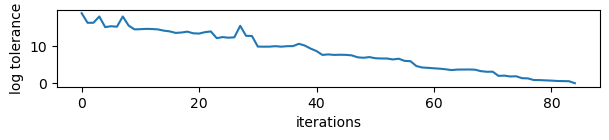

In [12]:
Plot_wend.cg_tolerance()

### SE Kernel

In [31]:
geom = Geometry(0, 0, 0, 0)

In [32]:
frank2d2 = Frank2D(N, rout, geom)

In [33]:
best = {'m': -1.995082249593998, 'c': 8501943831.276791, 'l': 57461.09572521277}

In [34]:
frank2d2.process_vis(uvtable_synthetic)

===>  Setting gridded data...


In [36]:
frank2d2.set_kernel(type_kernel = "SquareExponential", kernel_params = best)
frank2d2.set_x0(None)

===>  Setting GP Kernel SquareExponential...
     + Kernel parameters:  {'m': -1.995082249593998, 'c': 8501943831.276791, 'l': 57461.09572521277}


In [37]:
frank2d2.set_fit_method()

In [38]:
SE = frank2d2._kernel.sparse_matrix()

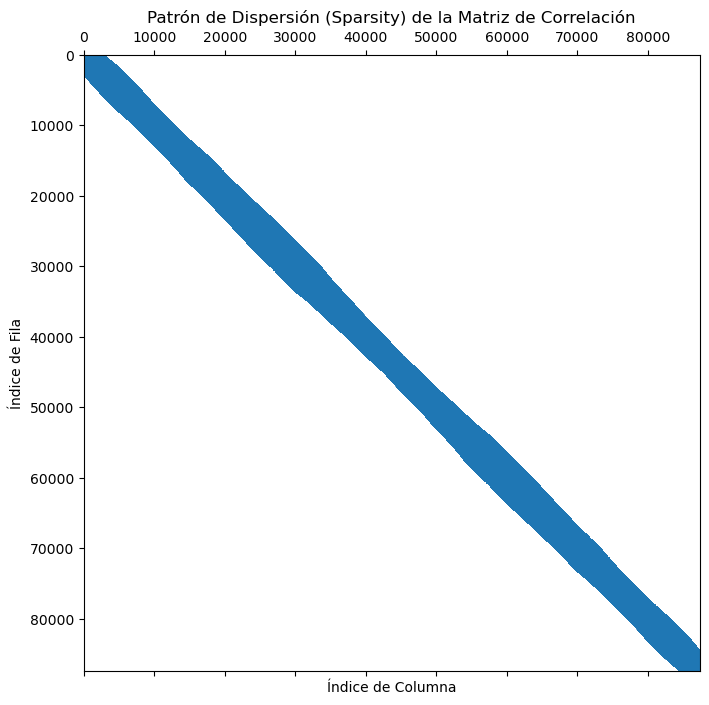

In [39]:
plt.figure(figsize=(10, 8))
plt.spy(SE, markersize=1)
plt.title("Patrón de Dispersión (Sparsity) de la Matriz de Correlación")
plt.xlabel("Índice de Columna")
plt.ylabel("Índice de Fila")
plt.show()

In [33]:
frank2d2.fit(
                data = uvtable_synthetic,
                kernel_params = params_1, rtol = 1e-8, 
                type_kernel = 'SquareExponential'
            )

Setting gridded data...
Setting GP Kernel SquareExponential...
 + Kernel parameters:  {'m': -2, 'c': 100000000.0, 'l': 70000.0}
Creating sparse linear system...
--> time kernel = 0.77  min |  46.00 seconds
Using preconditioner method:  jacobi
--> time building system = 0.79  min |  47.64 seconds
Solving linear system...
Running solver with maxiter =  50000  and rtol =  1e-08
         * rtol: 1e-08
         * final tolerance: 0.7524692980121811
Final tolerance :  0.7524692980121811
.... iteration:  0
                        -> actual tol:  75246929.8012181 vs  0.7524692980121811
.... iteration:  1
                        -> actual tol:  25838144.065486126 vs  0.7524692980121811
.... iteration:  2
                        -> actual tol:  12448728.319051322 vs  0.7524692980121811
.... iteration:  3
                        -> actual tol:  9150024.035387848 vs  0.7524692980121811
.... iteration:  4
                        -> actual tol:  2905356.7637954373 vs  0.7524692980121811
.... iterati

KeyboardInterrupt: 

In [106]:
Plot_ = Plot(frank2d2)

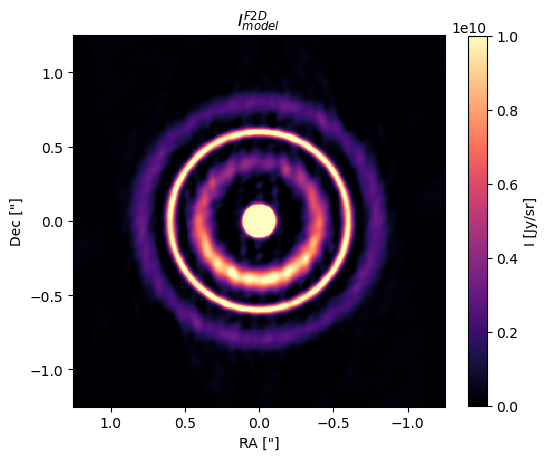

In [107]:
Plot_.intensity(vmax=1e10, gamma = 1, zoom = 3, title = r'$I_{model}^{F2D}$')

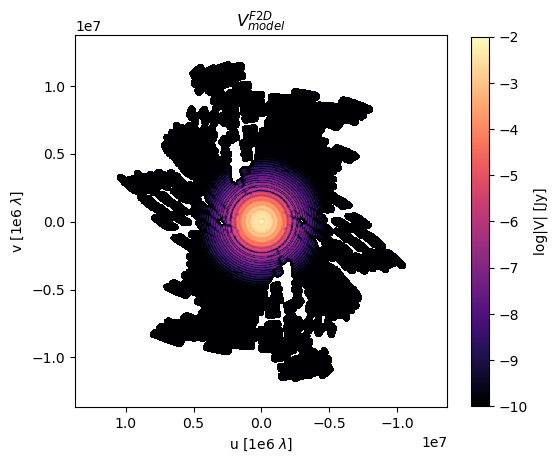

In [108]:
Plot_.visibility(fig_size=6, title= r'$V_{model}^{F2D}$')

### Visualize SE Kernel